In [1]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [4]:
# [단계 1] 구글 드라이브 연결 및 주류 판매량 데이터 가져오기

file_path = "/content/drive/MyDrive/가천대학교/2026-1/인공지능개론/Colab Notebooks/2. 데이터/TSLA.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)


         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [5]:
# 2. Open 가격을 사용하여 진행
data = df[["Open"]]

print(data.head())
print(data.shape)


    Open
0  3.800
1  5.158
2  5.000
3  4.600
4  4.000
(2956, 1)


In [8]:
# 훈련 데이터, 테스트 데이터 분리
# 시계열 데이터라 no shake, 80/20 비율로 사용
split = int(len(data) * 0.8)
train_data = data.iloc[:split]
test_data = data.iloc[split:]

print("train_data:", train_data.shape)
print("test_data:", test_data.shape)


train_data: (2364, 1)
test_data: (592, 1)


In [9]:
# train line fit (정규화)
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [11]:
# 시퀀스 생성
def make_sequence(data, window):
    X = []
    y = []

    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])# 다음 open 가격 예측
# window open 가격
    return np.array(X), np.array(y)

window = 30

X_train, y_train = make_sequence(train_scaled, window)
X_test, y_test = make_sequence(test_scaled, window)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2334, 30, 1)
y_train: (2334, 1)
X_test: (562, 30, 1)
y_test: (562, 1)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window,1)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

In [13]:
# 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(
        64,
        input_shape=(window, 1)
    ),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 만들어준 모델로 학습
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0033 - mae: 0.0327 - val_loss: 0.0020 - val_mae: 0.0350
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9356e-04 - mae: 0.0180 - val_loss: 0.0017 - val_mae: 0.0325
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.1329e-04 - mae: 0.0154 - val_loss: 0.0017 - val_mae: 0.0324
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.1055e-04 - mae: 0.0151 - val_loss: 0.0012 - val_mae: 0.0265
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.7777e-04 - mae: 0.0126 - val_loss: 0.0011 - val_mae: 0.0246
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 3.9457e-04 - mae: 0.0131 - val_loss: 0.0014 - val_mae: 0.0277
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 3.5530e-04 - mae: 0.0123 - val_loss: 9.6282e-04 - val_mae: 0.0230
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.9818e-04 - mae: 0.0111 - val_loss: 0.0012 - val_mae: 0.0250
Epoch 9/50
117/117 ━

In [18]:
# 평가 후 예측
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

pred = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 23.2572 - mae: 3.7867
Test Loss: 23.2571964263916
Test MAE: 3.7866857051849365
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [20]:
# 정규화 복원
# 우리가 알아 볼 수 있는 실제 값으로

y_test_real = scaler.inverse_transform(y_test)
pred_real = scaler.inverse_transform(pred)

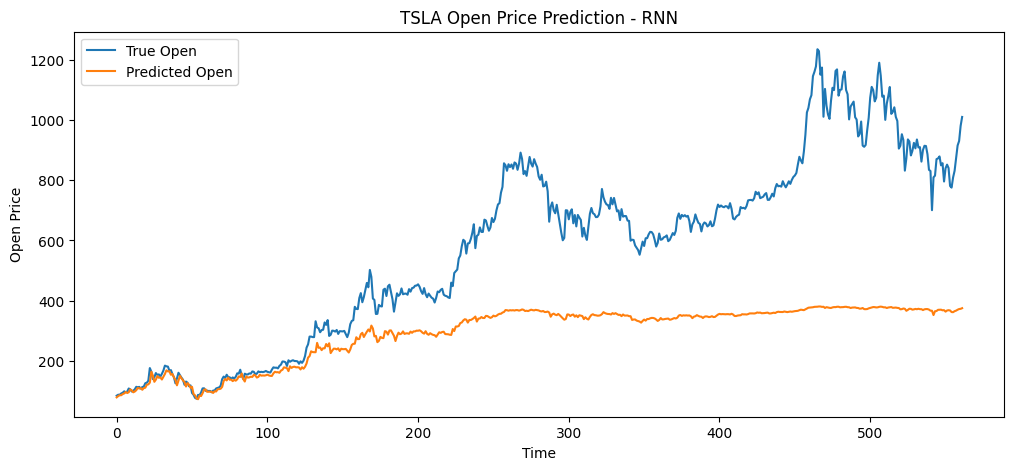

In [21]:
# true open과 pre open 시각화
plt.figure(figsize=(12, 5))
plt.plot(y_test_real, label="True Open")
plt.plot(pred_real, label="Predicted Open")
plt.title("TSLA Open Price Prediction - RNN")
plt.xlabel("Time")
plt.ylabel("Open Price")
plt.legend()
plt.show()